In [1]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

Frequenz unbelastet: 7.36+/-0.16
Frequenz belastet: 5.24+/-0.13
Leistung Zufuhr : 183.1+/-1.0
Leistung Motor : 4.6876+/-0.4288
idealer Wirkungsgrad : 0.77+/-0.04
Wirkungsgrad Maschine unbelastet : 10.10+/-0.32
Wirkungsgrad Maschine belastet : 0.0256+/-0.0023
Wirkungsgrad Motor belastet : 0.2587+/-0.0250
realer Wirkungsgrad : 0.0256+/-0.0023


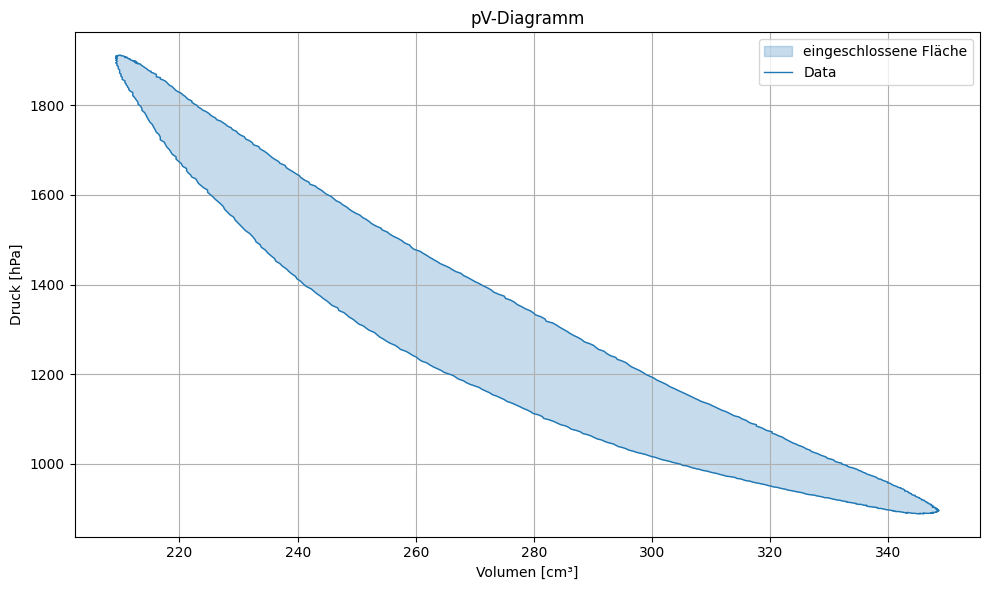

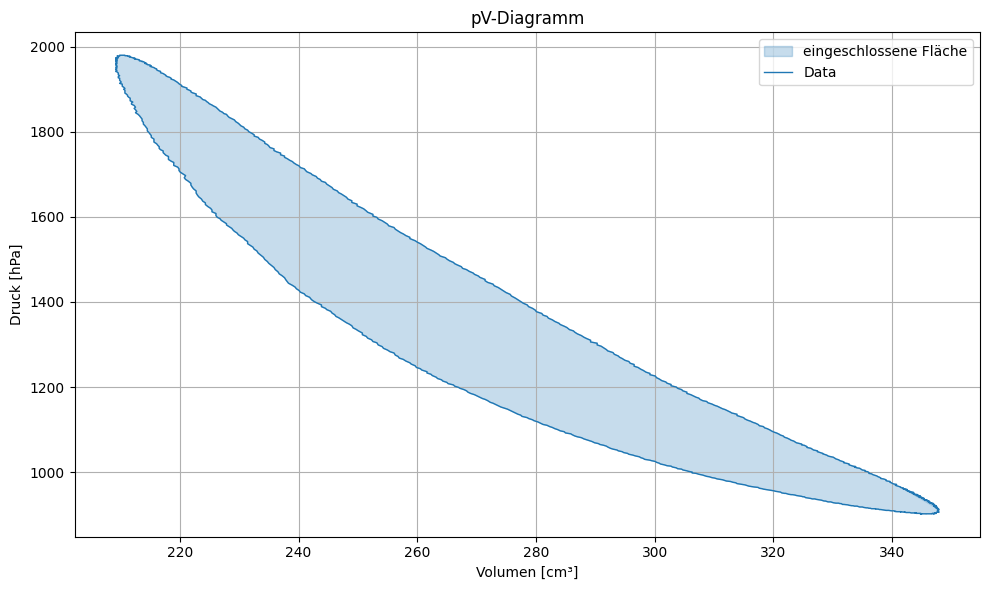

In [ ]:
p_x = 345*985/209


T_max = ufloat(950, 100) # °C Temperatur der Wärmequelle
T_min = ufloat(10, 5)   # °C Temperatur des kälte Reservouirs
f_0 = ufloat((72.80+74.41)/20, (74.41-72.8)/10) # 1/s Frequenz unbelastet
f_b = ufloat((53.00+51.71)/20, (53.00-51.71)/10)    # 1/s Frequenz belastet
F_l = ufloat(0.57,0.05) # N Belastungskraft
U_m = ufloat(13.56, 0.05) # V Spannun für Wärmequelle
I_m = ufloat(13.50, 0.05) # A Stromstärke der Wärmequelle
r_b = ufloat(25, 0.2)/100    # m länge des Stabs an dem die Kraft hängt
print(f"Frequenz unbelastet: {f_0}")
print(f"Frequenz belastet: {f_b}")

W_pv_b = ufloat(28710, 740)  # hPa*cm^3 Fläche des Graphen belastet
W_pv_b_n = W_pv_b*10**(-6)*100  # richtige Einheit Joule
P_z = U_m*I_m # V*A Leistung Maschine
P_m = F_l*r_b*2*c.pi*f_b        # Leistung Motor
W_pV_0 = ufloat(24620, 560) # hPa*cm^3 Fläche des Graphen unbelastet
W_pV_n = W_pV_0*10**(-6)*100    # richtige Einheit Joule

print(f"Leistung Zufuhr : {P_z}")
print(f"Leistung Motor : {P_m:.4f}")

def rho(P, f, W):   # Berechnung Wirkungsgrad
    return P/(f*W)


rho_i = rho(T_max-T_min,T_max + 273.15,1)    # idealer Wirkungsgrad
rho_m = rho(P_z, f_0, W_pV_n)   # Wirkungsgrad Maschine
rho_m_b = rho(P_m, P_z, 1)   # Wirkungsgrad Maschine belastet
rho_mo = rho(P_m,f_0,W_pV_n)    # Wirkungsgrad Motor
rho_r = rho(P_m, P_z, 1)    # Wirkungsgrad real
print(f"idealer Wirkungsgrad : {rho_i}")
print(f"Wirkungsgrad Maschine unbelastet : {rho_m}")
print(f"Wirkungsgrad Maschine belastet : {rho_m_b:.4f}")
print(f"Wirkungsgrad Motor belastet : {rho_mo:.4f}")
print(f"realer Wirkungsgrad : {rho_r}")


Data = pd.read_csv("PV-Di03-21.04.26.csv", sep=';', decimal=',')    # read csv für den Graphen unbelastet


p = Data["p"].to_numpy()    # Druck Data

V = Data["V"].to_numpy()    # Volumen Data



# Plot 
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.fill(V, p, color="C0", alpha=0.25, label="eingeschlossene Fläche")  # markiert die Fläche im Graphen
plt.plot(V, p, '-', linewidth=1, label="Data")
plt.xlabel("Volumen [cm³]")
plt.ylabel("Druck [hPa]")
plt.title("pV-Diagramm")
plt.legend()
plt.grid()
plt.tight_layout()

Data = pd.read_csv("PVb-Di03-21.04.26.csv", sep=';', decimal=',')   # read csv für den Graphen belastet


p = Data["p"].to_numpy()    # Druck Data

V = Data["V"].to_numpy()    # Volumen Data



# Plot with color gradient
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.fill(V, p, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(V, p, '-', linewidth=1, label="Data")
plt.xlabel("Volumen [cm³]")
plt.ylabel("Druck [hPa]")
plt.title("pV-Diagramm")
plt.legend()
plt.grid()
plt.tight_layout()

# Flavor


In [3]:
U_m = ufloat(232.2, 0.3)    # V Spannung des Motors
I_m = ufloat(0.33,0.05)    # A Stromstärke des Motors
U_geg = ufloat(5.44, 0.02)   # V    Gegenspannung der coil
I_geg = ufloat(1.22, 0.01)   # A    Gegenstromstärke der coil
T_m = ufloat(6.7, 0.8)  # °C    Temperatur der coil

P_m = U_m*I_m   # Leistung Motor
P_geg = U_geg*I_geg # Leistung coil
rho = P_geg/P_m # Wirkungsgrad

print(P_geg)
print(P_m)
print(rho)



6.64+/-0.06
77+/-12
0.087+/-0.013
